Ingrese el nombre del archivo de imagen (incluyendo la extensión): /content/Radio.jpg


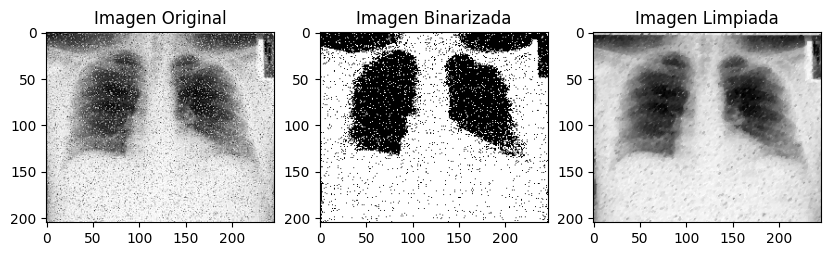

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import io
import skimage.color as color

# Función para cargar la imagen y procesarla
def cargarImagen():
    filename = input("Ingrese el nombre del archivo de imagen (incluyendo la extensión): ")

    # Leer la imagen
    img = io.imread(filename)

    # Convertir la imagen a escala de grises (si es necesario)
    if img.ndim == 3:
        img_gray = color.rgb2gray(img)
    else:
        img_gray = img

    # Binarizar la imagen
    _, img_bw = cv2.threshold((img_gray * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Crear el elemento estructurante
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))

    # Limpiar imagen binaria con apertura
    img_limpia_bw = cv2.morphologyEx(img_bw, cv2.MORPH_OPEN, se)

    # Limpiar imagen en escala de grises con apertura y cierre
    img_limpia_gray = cv2.morphologyEx((img_gray * 255).astype(np.uint8), cv2.MORPH_OPEN, se)
    img_limpia_gray = cv2.morphologyEx(img_limpia_gray, cv2.MORPH_CLOSE, se)

    # Limpiar imagen a color (si corresponde)
    if img.ndim == 3:  # Si es imagen a color
        img_limpia = np.zeros_like(img)
        for c in range(3):
            img_limpia[:,:,c] = cv2.morphologyEx(img[:,:,c], cv2.MORPH_OPEN, se)
            img_limpia[:,:,c] = cv2.morphologyEx(img_limpia[:,:,c], cv2.MORPH_CLOSE, se)
    else:
        img_limpia = img_limpia_gray

    # Mostrar las imágenes
    plt.figure(figsize=(10, 7))
    plt.subplot(1, 3, 1), plt.imshow(img, cmap='gray'), plt.title('Imagen Original')
    plt.subplot(1, 3, 2), plt.imshow(img_bw, cmap='gray'), plt.title('Imagen Binarizada')
    plt.subplot(1, 3, 3), plt.imshow(img_limpia, cmap='gray'), plt.title('Imagen Limpiada')
    plt.show()

# Llamar a la función para cargar la imagen
cargarImagen()
